In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras import layers, models

import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

In [2]:
train_dir = r"/content/drive/MyDrive/Dataset/Training"
test_dir = r"/content/drive/MyDrive/Dataset/Testing"
img_size = (224, 224)
batch_size = 32
epochs = 15
seed = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)


Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.


In [4]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)


Found 1600 files belonging to 4 classes.


In [5]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


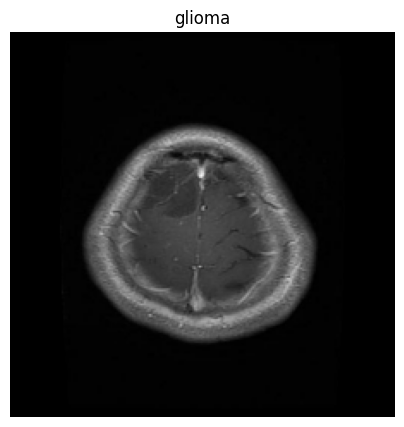

In [6]:
plt.figure(figsize=(5,5))

for images, labels in train_ds.take(1):
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(class_names[tf.argmax(labels[0])])
    plt.axis("off")

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
])

train_ds = train_ds.map(lambda x, y: (preprocess_input(data_augmentation(x)), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))


In [8]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])


In [10]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(
            name="auc",
            multi_label=True
        )
    ]

)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop]
)


Epoch 1/15
 40/149 ━━━━━━━━━━━━━━━━━━━━ 8:37 5s/step - accuracy: 0.5420 - auc: 0.7641 - loss: 1.2429

In [ ]:
loss, accuracy, auc_metric = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)


In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
y_true = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

In [ ]:
y_pred_prob = model.predict(test_ds)

In [ ]:
y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(num_classes)
)

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC={roc_auc:.2f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "k--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
overall_auc = roc_auc_score(
    y_true_bin,
    y_pred_prob,
    multi_class="ovr"
)

print("Overall AUC:", overall_auc)

In [ ]:
model.save("brain_tumor_model.keras")